Reference: [K-Nearest Neighbors Classification From Scratch in Python (Mathematical)](https://youtu.be/xtaom__-drE?si=TQHmqoWU77-Ht_sp)

#### 1. What are we trying to do?

This code implements a very simple K-Nearest Neighbors (KNN) classifier.

We already know that some points are:
🔵 blue
🔴 red

And we have a new point:(3, 3)

Imagine we have points on a 2D graph:
```text
       y
       ↑
   6          🔴 🔴
   5        🔴 🔴
   4    🔵            🔴
   3  🔵 🔵 🆕
   2      🔵
   1    🔵
       └────────────→ x
```
We want the computer to answer: Is (3,3) blue or red?

KNN does this by asking: Which existing points are closest to (3,3)?

In [ ]:
# numpy for working with array 
import numpy as np
# Matplotlib is used to create graphs and plots.
import matplotlib.pyplot as plt
# Counter is a Python tool that counts things.
from collections import Counter

# existing points
points = {
    "blue":[[2,4], [1,3], [2,3], [3,2], [2,1]],
    "red": [[5,6], [4,5], [4,6], [6,6], [5,4]]
}

# test point
new_point =[3,3]


blue


#### Euclidean distance  is a straight line distance two points
$$
d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

$d(x,y)$ → distance between x and y  
$\sqrt{...}$ → square root  
$\sum$ → summation  
$i=1$ → start at $i=1$  
$n$ → end at $n$  
$x_i-y_i$ → difference between the i-th values  
$^2$ → squared

In [11]:
# Straight line distance
def euclidean_distance(p, q):
    np.sqrt(np.sum((np.array(p) - np.array(q))**2))

In [ ]:
class KNearestNeighbors:
    def __init__(self, k=3):
        self.k = k
        self.point = None

    # Create a function called fit. Give it some points, and store those points inside this object.
    def fit(self, points):
        self.points = points

    # Create a function that receives a new point and predicts its category.
    def predict(self, new_points):

        # create an empty list because we're going to calculate distances and put them inside this list.
        distances = []
        
        for category in self.points:
            # self.points[category] -> self.points["blue"] -> [[2,4], [1,3], [2,3], [3,2], [2,1]]
            for point in self.points[category]:
                # calculate
                distance = euclidean_distance(point, new_points)
                distances.append([distance, category])

        # categories = []
        # nearest_points = sorted(distances)[:self.k]
        # for item in nearest_points:
            # categories.append(item[1]) //item = [1.000, "blue"]
        categories = [category[1] for category in sorted(distances)[:self.k]]
        # Counter().most_common(1) -> [("blue", 3)]
        # most_common(1): 1 means give me 1 common item
        result = Counter(categories).most_common(1)[0][0]
        return result

In [ ]:
# create a KNN object
clf = KNearestNeighbors()

clf.fit(points)
print(clf.predict(new_point))

blue


#### Visualize

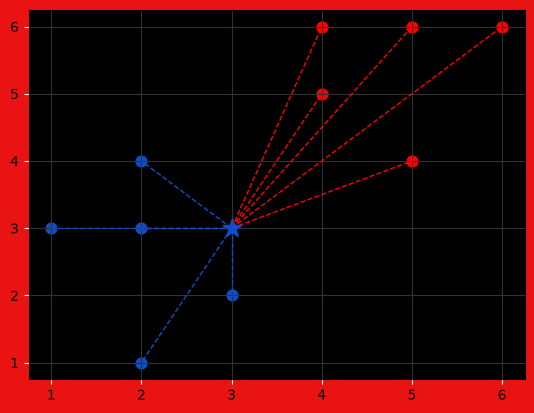

In [ ]:
# create Axe 
ax = plt.subplot()

# True: show the grid
ax.grid(True, color="#323232")
# set_facecolor: Making the background black (inside with the grid)
ax.set_facecolor("black")
# set the overall background (outside)
ax.figure.set_facecolor("#EA1313")

# Changing the axis colors
ax.tick_params(axis="x", color="white")
ax.tick_params(axis="y", color="white")

# drawing blue points
for point in points['blue']:
    # suppose point = (3, 7) => point[0]= 3, point[1]= 7, Plot a point at x = 3, y = 7
    # s=60 -> controls the point size.
    ax.scatter(point[0], point[1], color="#104DCA", s=60)

# drawing red points
for point in points['red']:
    ax.scatter(point[0], point[1], color="#FF0000", s=60)

new_class = clf.predict(new_point)

color = "#FF0000" if new_class == "red" else "#104DCA"

# Drawing the new point
ax.scatter(
    new_point[0],
    new_point[1],
    color=color,
    marker="*",
    s=200,
    zorder=100
)

# drawing lines
for point in points['blue']:
    ax.plot(
        [new_point[0], point[0]],
        [new_point[1], point[1]],
        color="#104DCA",
        linestyle="--",
        linewidth=1
    )

for point in points['red']:
    ax.plot(
        [new_point[0], point[0]],
        [new_point[1], point[1]],
        color="#FF0000",
        linestyle="--",
        linewidth=1
    )

plt.show()

![Model diagram](image/2d_prediction.png)